# Flight Price Prediction - Exploratory Data Analysis (EDA)

This notebook provides a comprehensive exploratory data analysis of the flight dataset to identify which features are related to the target variable (price).

## 1. Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, spearmanr, pearsonr
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 2. Load and Explore Dataset

In [4]:
# Load the data
df = pd.read_csv('../data/data.csv', index_col=0)

# Display basic information
print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nData Types:")
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (300153, 11)

First 5 rows:
    airline   flight source_city departure_time stops   arrival_time  \
0  SpiceJet  SG-8709       Delhi        Evening  zero          Night   
1  SpiceJet  SG-8157       Delhi  Early_Morning  zero        Morning   
2   AirAsia   I5-764       Delhi  Early_Morning  zero  Early_Morning   
3   Vistara   UK-995       Delhi        Morning  zero      Afternoon   
4   Vistara   UK-963       Delhi        Morning  zero        Morning   

  destination_city    class  duration  days_left  price  
0           Mumbai  Economy      2.17          1   5953  
1           Mumbai  Economy      2.33          1   5953  
2           Mumbai  Economy      2.17          1   5956  
3           Mumbai  Economy      2.25          1   5955  
4           Mumbai  Economy      2.33          1   5955  

Data Types:
airline                 str
flight                  str
source_city             str
departure_time          str
stops                   str
arrival_time           

In [5]:
# Basic statistics
print("\n" + "="*50)
print("DESCRIPTIVE STATISTICS")
print("="*50)
print(df.describe())

print("\nCategorical Features:")
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print(categorical_cols)

print("\nNumeric Features:")
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(numeric_cols)


DESCRIPTIVE STATISTICS
            duration      days_left          price
count  300153.000000  300153.000000  300153.000000
mean       12.221021      26.004751   20889.660523
std         7.191997      13.561004   22697.767366
min         0.830000       1.000000    1105.000000
25%         6.830000      15.000000    4783.000000
50%        11.250000      26.000000    7425.000000
75%        16.170000      38.000000   42521.000000
max        49.830000      49.000000  123071.000000

Categorical Features:
['airline', 'flight', 'source_city', 'departure_time', 'stops', 'arrival_time', 'destination_city', 'class']

Numeric Features:
['duration', 'days_left', 'price']



TARGET VARIABLE - PRICE
count    300153.000000
mean      20889.660523
std       22697.767366
min        1105.000000
25%        4783.000000
50%        7425.000000
75%       42521.000000
max      123071.000000
Name: price, dtype: float64

Skewness: 1.0614
Kurtosis: -0.3963


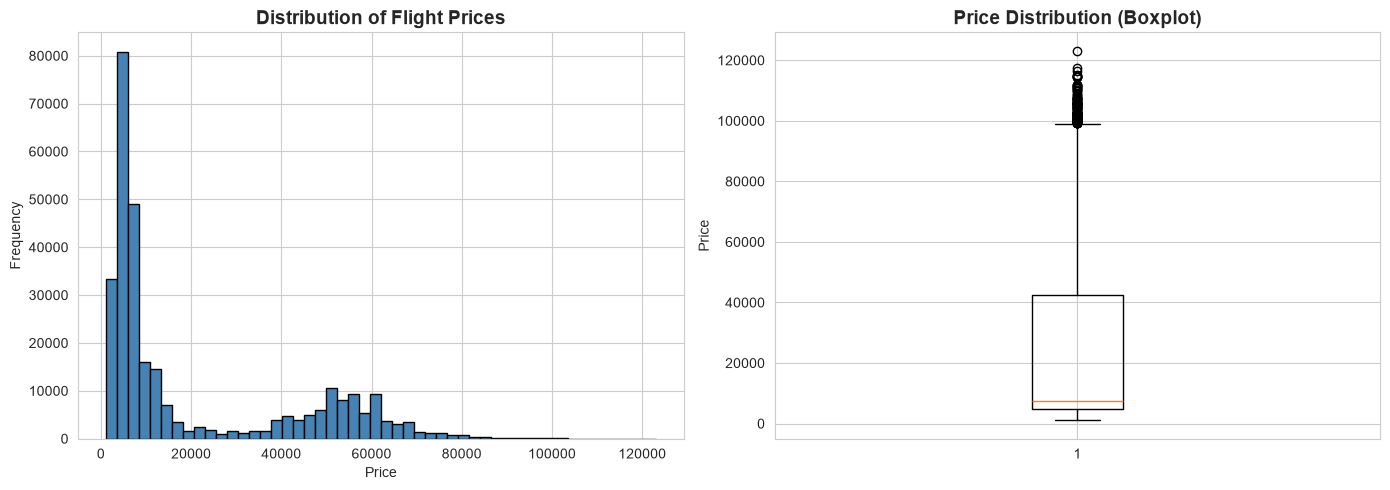

In [6]:
# Target variable distribution
print("\n" + "="*50)
print("TARGET VARIABLE - PRICE")
print("="*50)
print(df['price'].describe())
print(f"\nSkewness: {df['price'].skew():.4f}")
print(f"Kurtosis: {df['price'].kurtosis():.4f}")

# Visualize target distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['price'], bins=50, color='steelblue', edgecolor='black')
axes[0].set_title('Distribution of Flight Prices', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Price')
axes[0].set_ylabel('Frequency')

axes[1].boxplot(df['price'])
axes[1].set_title('Price Distribution (Boxplot)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Price')

plt.tight_layout()
plt.show()

## 3. Numeric Features Analysis

In [7]:
# Correlation analysis
numeric_data = df[['duration', 'days_left', 'price']]
correlation_matrix = numeric_data.corr()

print("\n" + "="*50)
print("CORRELATION MATRIX")
print("="*50)
print(correlation_matrix)

# Correlation with target
print("\n" + "="*50)
print("CORRELATION WITH TARGET (PRICE)")
print("="*50)
price_corr = correlation_matrix['price'].drop('price').sort_values(ascending=False)
print(price_corr)
print("\nInterpretation:")
for col, corr in price_corr.items():
    strength = 'Strong' if abs(corr) > 0.5 else 'Moderate' if abs(corr) > 0.3 else 'Weak'
    direction = 'Positive' if corr > 0 else 'Negative'
    print(f"  {col}: {direction} correlation ({corr:.4f}) - {strength}")


CORRELATION MATRIX
           duration  days_left     price
duration   1.000000  -0.039157  0.204222
days_left -0.039157   1.000000 -0.091949
price      0.204222  -0.091949  1.000000

CORRELATION WITH TARGET (PRICE)
duration     0.204222
days_left   -0.091949
Name: price, dtype: float64

Interpretation:
  duration: Positive correlation (0.2042) - Weak
  days_left: Negative correlation (-0.0919) - Weak


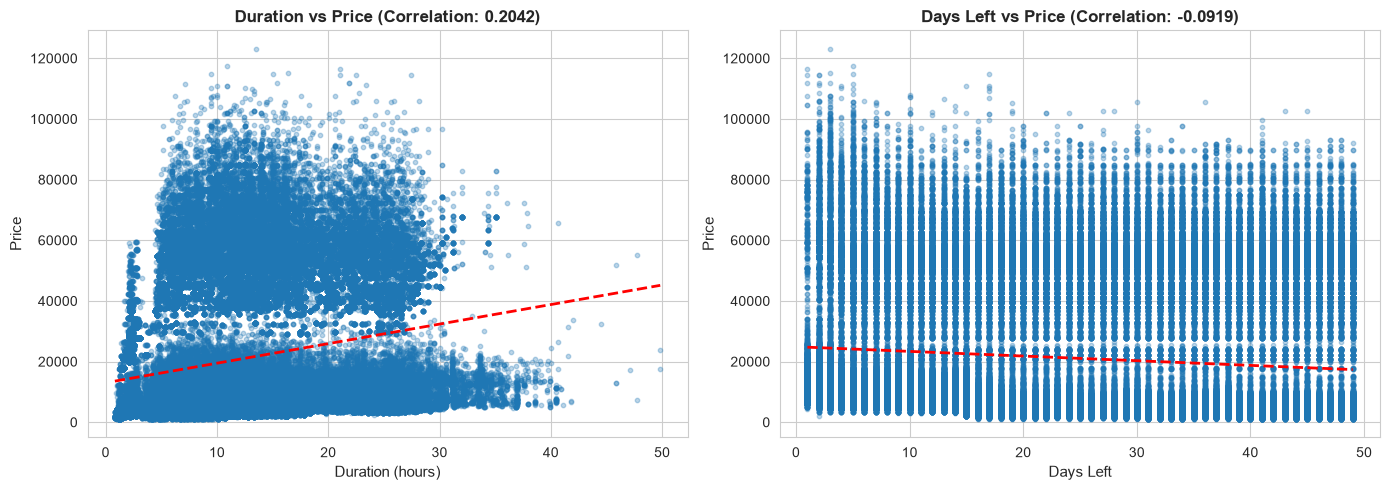

In [8]:
# Visualize numeric correlations
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Duration vs Price
axes[0].scatter(df['duration'], df['price'], alpha=0.3, s=10)
z = np.polyfit(df['duration'], df['price'], 1)
p = np.poly1d(z)
axes[0].plot(df['duration'].sort_values(), p(df['duration'].sort_values()), "r--", linewidth=2)
axes[0].set_xlabel('Duration (hours)', fontsize=11)
axes[0].set_ylabel('Price', fontsize=11)
axes[0].set_title(f'Duration vs Price (Correlation: {price_corr["duration"]:.4f})', fontsize=12, fontweight='bold')

# Days Left vs Price
axes[1].scatter(df['days_left'], df['price'], alpha=0.3, s=10)
z = np.polyfit(df['days_left'], df['price'], 1)
p = np.poly1d(z)
axes[1].plot(df['days_left'].sort_values(), p(df['days_left'].sort_values()), "r--", linewidth=2)
axes[1].set_xlabel('Days Left', fontsize=11)
axes[1].set_ylabel('Price', fontsize=11)
axes[1].set_title(f'Days Left vs Price (Correlation: {price_corr["days_left"]:.4f})', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

## 4. Categorical Features Analysis

In [9]:
# Analyze categorical features
categorical_features = ['airline', 'source_city', 'departure_time', 'stops', 'arrival_time', 'destination_city', 'class']

print("\n" + "="*50)
print("CATEGORICAL FEATURES ANALYSIS")
print("="*50)

categorical_relationships = {}

for col in categorical_features:
    print(f"\n{col.upper()}:")
    print(f"  Unique values: {df[col].nunique()}")
    
    # Calculate Cramér's V for association with target
    contingency_table = pd.crosstab(df[col], pd.cut(df['price'], bins=10))
    chi2, p_value, dof, expected = chi2_contingency(contingency_table)
    
    n = contingency_table.sum().sum()
    min_dim = min(contingency_table.shape) - 1
    cramers_v = np.sqrt(chi2 / (n * min_dim)) if min_dim > 0 else 0
    
    categorical_relationships[col] = cramers_v
    print(f"  Cramér's V with Price: {cramers_v:.4f}")
    print(f"  P-value: {p_value:.4e}")
    
    # Mean price by category
    print(f"  Mean price by category:")
    mean_prices = df.groupby(col)['price'].agg(['mean', 'count']).sort_values('mean', ascending=False).head(5)
    print(mean_prices)


CATEGORICAL FEATURES ANALYSIS

AIRLINE:
  Unique values: 6
  Cramér's V with Price: 0.2308
  P-value: 0.0000e+00
  Mean price by category:
                   mean   count
airline                        
Vistara    30396.536302  127859
Air_India  23507.019112   80892
SpiceJet    6179.278881    9011
GO_FIRST    5652.007595   23173
Indigo      5324.216303   43120

SOURCE_CITY:
  Unique values: 6
  Cramér's V with Price: 0.0743
  P-value: 0.0000e+00
  Mean price by category:
                     mean  count
source_city                     
Chennai      21995.339871  38700
Kolkata      21746.235679  46347
Mumbai       21483.818839  60896
Bangalore    21469.460575  52061
Hyderabad    20155.623879  40806

DEPARTURE_TIME:
  Unique values: 6
  Cramér's V with Price: 0.0447
  P-value: 0.0000e+00
  Mean price by category:
                        mean  count
departure_time                     
Night           23062.146808  48015
Morning         21630.760254  71146
Evening         21232.361894  65

In [10]:
# Rank categorical features by their relationship strength
print("\n" + "="*50)
print("CATEGORICAL FEATURES RANKED BY RELATIONSHIP WITH PRICE")
print("="*50)

ranked_categorical = sorted(categorical_relationships.items(), key=lambda x: x[1], reverse=True)
for i, (feature, cramers_v) in enumerate(ranked_categorical, 1):
    strength = 'Strong' if cramers_v > 0.3 else 'Moderate' if cramers_v > 0.15 else 'Weak'
    print(f"{i}. {feature:20s}: {cramers_v:.4f} ({strength})")


CATEGORICAL FEATURES RANKED BY RELATIONSHIP WITH PRICE
1. class               : 0.9746 (Strong)
2. stops               : 0.2417 (Moderate)
3. airline             : 0.2308 (Moderate)
4. source_city         : 0.0743 (Weak)
5. arrival_time        : 0.0711 (Weak)
6. destination_city    : 0.0693 (Weak)
7. departure_time      : 0.0447 (Weak)


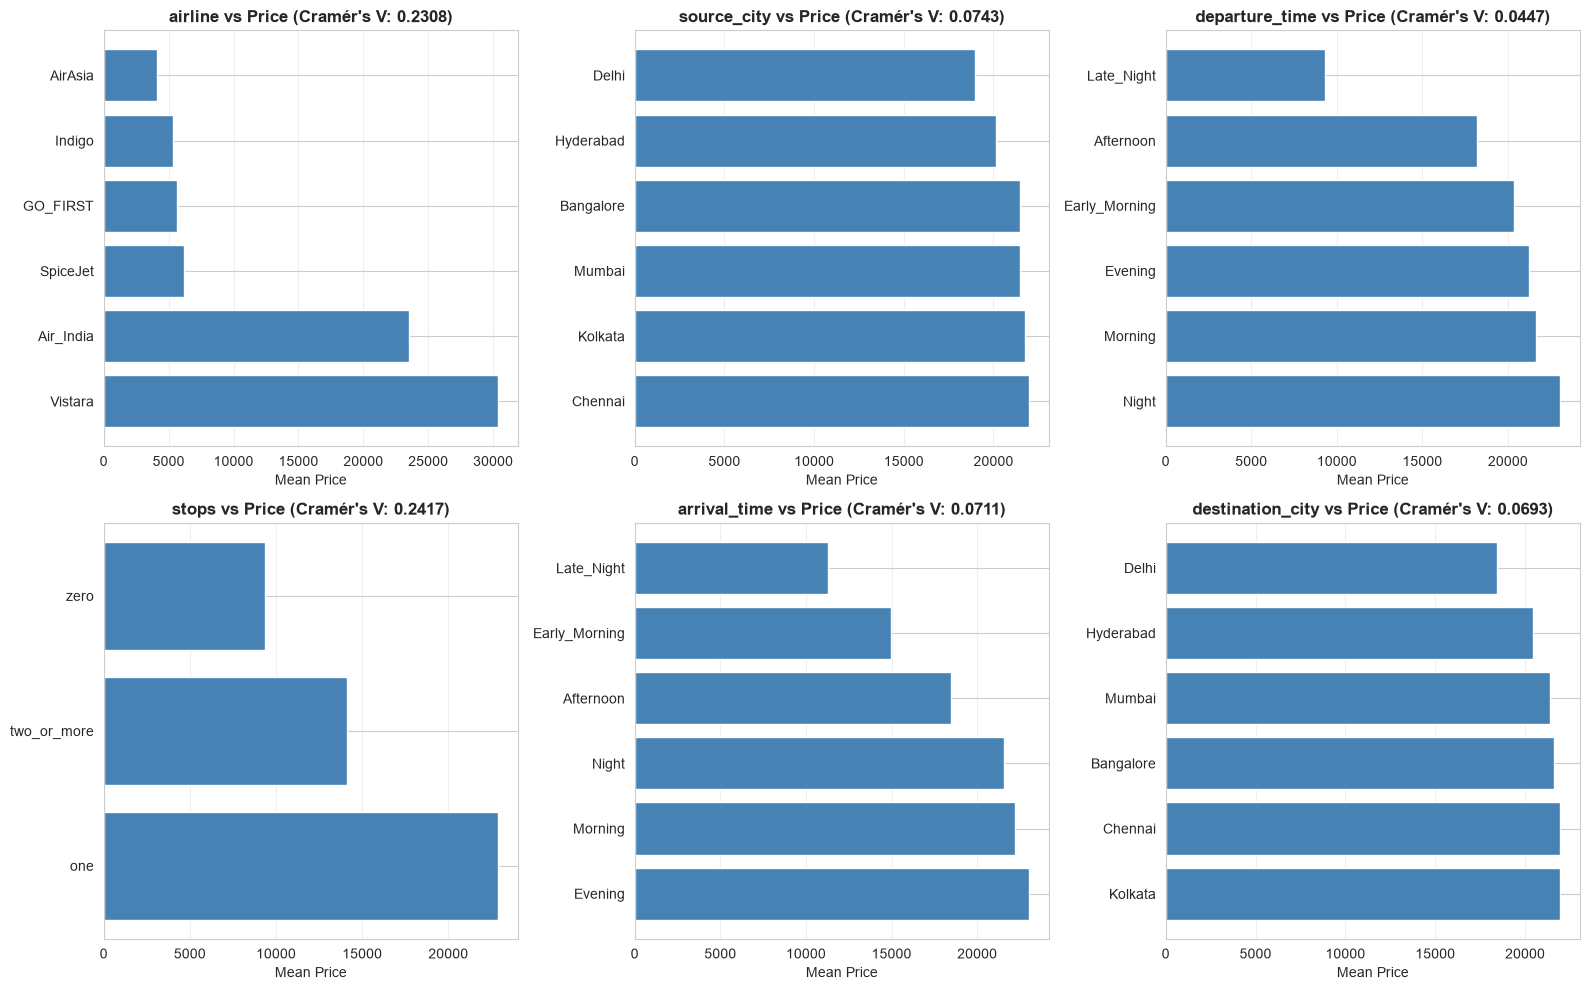

In [11]:
# Visualize categorical relationships
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, col in enumerate(categorical_features[:6]):
    data_to_plot = df.groupby(col)['price'].mean().sort_values(ascending=False)
    axes[idx].barh(data_to_plot.index, data_to_plot.values, color='steelblue')
    axes[idx].set_xlabel('Mean Price')
    axes[idx].set_title(f'{col} vs Price (Cramér\'s V: {categorical_relationships[col]:.4f})', fontweight='bold')
    axes[idx].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

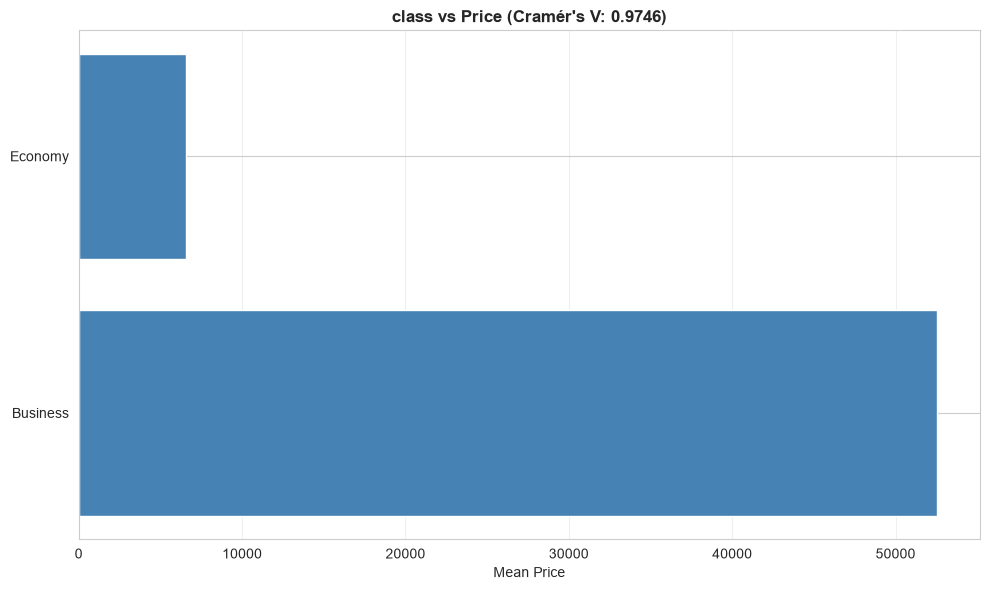

In [12]:
# Visualize the last categorical feature
fig, ax = plt.subplots(figsize=(10, 6))
data_to_plot = df.groupby('class')['price'].mean().sort_values(ascending=False)
ax.barh(data_to_plot.index, data_to_plot.values, color='steelblue')
ax.set_xlabel('Mean Price')
ax.set_title(f'class vs Price (Cramér\'s V: {categorical_relationships["class"]:.4f})', fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Feature Importance Summary

In [13]:
# Create comprehensive feature importance ranking
print("\n" + "="*70)
print("FEATURE IMPORTANCE SUMMARY - RELATIONSHIP WITH PRICE")
print("="*70)

all_features = {}

# Add numeric features
for col in ['duration', 'days_left']:
    corr = abs(df[col].corr(df['price']))
    all_features[col] = ('Numeric', corr)

# Add categorical features
for col in categorical_features:
    all_features[col] = ('Categorical', categorical_relationships[col])

# Sort by importance
sorted_features = sorted(all_features.items(), key=lambda x: x[1][1], reverse=True)

print(f"\n{'Rank':<6} {'Feature':<20} {'Type':<12} {'Importance':<12} {'Relationship'}")
print("-" * 70)

for rank, (feature, (feature_type, importance)) in enumerate(sorted_features, 1):
    if importance > 0.3:
        relationship = "STRONG"
    elif importance > 0.15:
        relationship = "MODERATE"
    else:
        relationship = "WEAK"
    
    print(f"{rank:<6} {feature:<20} {feature_type:<12} {importance:<12.4f} {relationship}")

print("\n" + "="*70)


FEATURE IMPORTANCE SUMMARY - RELATIONSHIP WITH PRICE

Rank   Feature              Type         Importance   Relationship
----------------------------------------------------------------------
1      class                Categorical  0.9746       STRONG
2      stops                Categorical  0.2417       MODERATE
3      airline              Categorical  0.2308       MODERATE
4      duration             Numeric      0.2042       MODERATE
5      days_left            Numeric      0.0919       WEAK
6      source_city          Categorical  0.0743       WEAK
7      arrival_time         Categorical  0.0711       WEAK
8      destination_city     Categorical  0.0693       WEAK
9      departure_time       Categorical  0.0447       WEAK



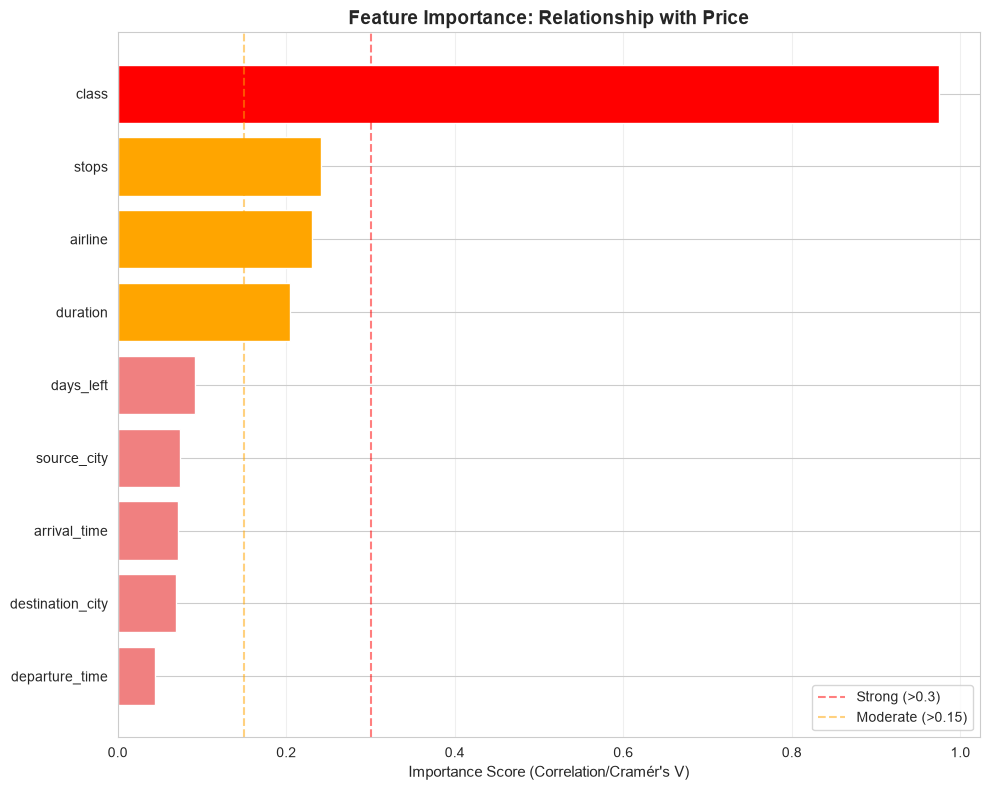

In [14]:
# Visualize feature importance
features_names = [x[0] for x in sorted_features]
features_importance = [x[1][1] for x in sorted_features]
features_colors = ['red' if imp > 0.3 else 'orange' if imp > 0.15 else 'lightcoral' for imp in features_importance]

fig, ax = plt.subplots(figsize=(10, 8))
y_pos = np.arange(len(features_names))
ax.barh(y_pos, features_importance, color=features_colors)
ax.set_yticks(y_pos)
ax.set_yticklabels(features_names)
ax.invert_yaxis()
ax.set_xlabel('Importance Score (Correlation/Cramér\'s V)', fontsize=11)
ax.set_title('Feature Importance: Relationship with Price', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

# Add threshold lines
ax.axvline(x=0.3, color='red', linestyle='--', alpha=0.5, label='Strong (>0.3)')
ax.axvline(x=0.15, color='orange', linestyle='--', alpha=0.5, label='Moderate (>0.15)')
ax.legend()

plt.tight_layout()
plt.show()

## 6. Summary and Conclusions

In [15]:
print("\n" + "="*70)
print("EDA SUMMARY & KEY FINDINGS")
print("="*70)

# Strong features
strong_features = [f[0] for f in sorted_features if f[1][1] > 0.3]
print(f"\n✓ STRONG FEATURES (Importance > 0.3):")
if strong_features:
    for feature in strong_features:
        print(f"  - {feature}")
else:
    print("  None (all features show weak to moderate relationships)")

# Moderate features
moderate_features = [f[0] for f in sorted_features if 0.15 < f[1][1] <= 0.3]
print(f"\n✓ MODERATE FEATURES (0.15 < Importance ≤ 0.3):")
if moderate_features:
    for feature in moderate_features:
        print(f"  - {feature}")
else:
    print("  None")

# Weak features
weak_features = [f[0] for f in sorted_features if f[1][1] <= 0.15]
print(f"\n✓ WEAK FEATURES (Importance ≤ 0.15):")
for feature in weak_features:
    print(f"  - {feature}")

print("\n" + "="*70)
print("RECOMMENDATIONS")
print("="*70)
print("""
1. FEATURE ENGINEERING: Consider creating interaction features between 
   moderate and weak features to capture combined effects.

2. MODEL SELECTION: Since we have weak linear relationships, consider:
   - Tree-based models (Random Forest, XGBoost, LightGBM)
   - Non-linear models (Neural Networks, SVR)
   
3. CATEGORICAL ENCODING: Use appropriate encoding for categorical variables:
   - One-hot encoding for low cardinality features
   - Target encoding for high cardinality features

4. FEATURE SELECTION: Focus on the moderate and strong features identified
   in this analysis for your predictive model.
""")
print("="*70)


EDA SUMMARY & KEY FINDINGS

✓ STRONG FEATURES (Importance > 0.3):
  - class

✓ MODERATE FEATURES (0.15 < Importance ≤ 0.3):
  - stops
  - airline
  - duration

✓ WEAK FEATURES (Importance ≤ 0.15):
  - days_left
  - source_city
  - arrival_time
  - destination_city
  - departure_time

RECOMMENDATIONS

1. FEATURE ENGINEERING: Consider creating interaction features between 
   moderate and weak features to capture combined effects.

2. MODEL SELECTION: Since we have weak linear relationships, consider:
   - Tree-based models (Random Forest, XGBoost, LightGBM)
   - Non-linear models (Neural Networks, SVR)

3. CATEGORICAL ENCODING: Use appropriate encoding for categorical variables:
   - One-hot encoding for low cardinality features
   - Target encoding for high cardinality features

4. FEATURE SELECTION: Focus on the moderate and strong features identified
   in this analysis for your predictive model.



**✏️Final Note for Features and Target**
<br>
<br>
**Input Features (X)**
1) class → Economy / Business
2) airline → Airline name
3) duration → Flight duration
4) source_city → Departure city
5) destination_city → Arrival city

**Target (y)** 
1) price → Flight ticket price 🎯

In [16]:
print(df["source_city"].unique())
print(df["destination_city"].unique())

<ArrowStringArray>
['Delhi', 'Mumbai', 'Bangalore', 'Kolkata', 'Hyderabad', 'Chennai']
Length: 6, dtype: str
<ArrowStringArray>
['Mumbai', 'Bangalore', 'Kolkata', 'Hyderabad', 'Chennai', 'Delhi']
Length: 6, dtype: str


In [17]:
print(df["airline"].unique())
print(df["class"].unique())

<ArrowStringArray>
['SpiceJet', 'AirAsia', 'Vistara', 'GO_FIRST', 'Indigo', 'Air_India']
Length: 6, dtype: str
<ArrowStringArray>
['Economy', 'Business']
Length: 2, dtype: str
